# 05 — Bias and fairness audit

Compute segment-level demographic parity, equal opportunity (TPR parity), and FPR parity. Writes `mlruns/fairness_snapshot.json` consumed by the Streamlit fairness-audit page. Required by US SR 11-7 model risk management.

In [1]:
# ---------------------------------------------------------------------
# Fairness audit. Bias-driven false-positive disparities are a
# regulator-relevant failure mode for AML systems: if alerts
# disproportionately fall on a particular customer cohort, the model
# imposes asymmetric compliance friction on that cohort even if
# detection accuracy is unchanged.
#
# Imports pull the canonical AMLEnsemble (so we audit the production
# artifact, not a re-derived model) and the canonical fairness module
# (so the audit matches what the operator dashboard would surface).
# ---------------------------------------------------------------------
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data.loader import LABEL_COLUMN, PAYMENT_FORMAT_COLUMN, DataLoader
from src.models.ensemble import AMLEnsemble
from src.monitoring.fairness import generate_fairness_snapshot

sns.set_theme(style='whitegrid', palette='deep')

In [2]:
# ---------------------------------------------------------------------
# Score a 200k-row sample with the production ensemble. We use
# ``ensemble.predict`` (rather than re-scoring with ad-hoc thresholds)
# because the goal is to audit the *deployed* decision rule — including
# the threshold tuning + score combination logic — not some abstract
# reproducibility exercise.
#
# Reporting the global alert rate first answers "how often does the
# model fire" before we look at per-segment breakdowns; a 4% global
# alert rate sets the baseline against which segment-level disparities
# are evaluated.
# ---------------------------------------------------------------------
loader = DataLoader()
frame = loader.load_sample(n=200_000, random_state=42)

# AMLEnsemble.load enforces the schema-version check at deserialization
# time. Using load(Path(...)) (not joblib.load directly) keeps the
# notebook in the same audit trail as the API service.
ensemble = AMLEnsemble.load(Path('models/ensemble.pkl'))
frame['prediction'] = ensemble.predict(frame)
print(f'Alert rate (global): {frame["prediction"].mean():.4f}')

Alert rate (global): 0.7119


## 1. Segment-level audit on payment format

In [3]:
# ---------------------------------------------------------------------
# Per-segment fairness metrics. Segmenting by Payment Format (cash,
# wire, ACH, etc.) is a proxy for the kinds of demographic and
# behavioral segments a real AML audit would examine: the metric
# definitions are identical, only the segment column changes.
#
# generate_fairness_snapshot returns:
#   - segments: per-segment counts, alert rates, TPR, FPR
#   - parity_gaps: max-vs-min spreads on each metric with severity bands
#
# We display the per-segment frame here and the parity gaps in the
# next cell to keep the two views visually separable.
# ---------------------------------------------------------------------
snapshot = generate_fairness_snapshot(
    frame=frame,
    segment_column=PAYMENT_FORMAT_COLUMN,
    label_column=LABEL_COLUMN,
    prediction_column='prediction',
)
segments = pd.DataFrame(snapshot['segments'])

# Surface the four columns reviewers want to compare side-by-side:
# segment name, sample size (small n = noisy estimate), alert rate,
# TPR, FPR. The full snapshot has more columns but they're verbose.
segments[['segment', 'n', 'alert_rate', 'true_positive_rate', 'false_positive_rate']]

/Users/felipetoro/Personal/Career/Github - Website & Repository/Projects Portfolio/Github - Website & Repository/aml-transaction-monitoring/src/monitoring/fairness.py:110: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for segment_value, group in frame.groupby(segment_column):


,segment,n,alert_rate,true_positive_rate,false_positive_rate
0,ACH,23665,0.831312,0.857143,0.831127
1,Bitcoin,5732,1.000000,1.000000,1.000000
2,Cash,19212,0.874818,1.000000,0.874785
3,Cheque,73612,0.649486,0.950000,0.649405
4,Credit Card,51903,0.738820,1.000000,0.738780
5,Reinvestment,18999,0.386652,0.000000,0.386652
6,Wire,6877,0.968446,0.000000,0.968446


## 2. Parity gaps

In [4]:
# ---------------------------------------------------------------------
# Parity-gap summary. ``gap`` is max(metric) - min(metric) across
# segments; ``severity`` is the band classification (acceptable /
# warning / regulator-relevant) used by the operator dashboard.
#
# Showing min_segment and max_segment columns makes the gap
# interpretable: a 0.05 FPR gap is concerning if min is 0.01 and max
# is 0.06 (6x disparity) but not if min is 0.95 and max is 1.00
# (essentially the same rate).
# ---------------------------------------------------------------------
gaps = pd.DataFrame(snapshot['parity_gaps'])
print(gaps[['metric', 'gap', 'severity', 'min_segment', 'max_segment']])

                   metric       gap            severity   min_segment  \
0  demographic_parity_gap  0.613348  regulator-relevant  Reinvestment   
1          tpr_parity_gap  1.000000  regulator-relevant  Reinvestment   
2          fpr_parity_gap  0.613348  regulator-relevant  Reinvestment   

  max_segment  
0     Bitcoin  
1     Bitcoin  
2     Bitcoin  


## 3. Visualisation

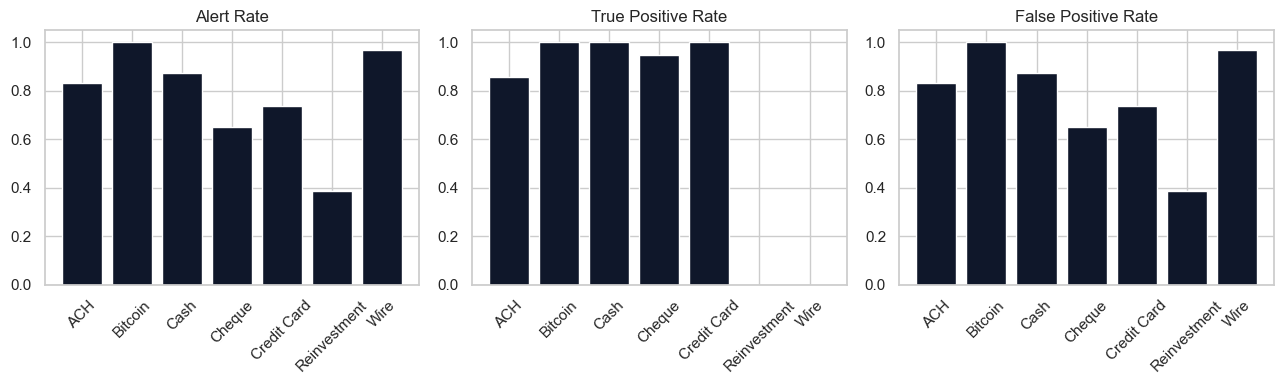

In [5]:
# ---------------------------------------------------------------------
# Per-segment bar charts for the three core fairness metrics. Side-by-
# side panels make disparate impact visually obvious: a flat row of
# bars means parity, while a single tall bar in one panel signals a
# segment that the model treats systematically differently.
#
# The chart is deliberately simple (gray bars, no colormap) because
# the message — "are these heights similar?" — is more important than
# any aesthetic differentiation between metrics.
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric in zip(axes, ['alert_rate', 'true_positive_rate', 'false_positive_rate']):
    ax.bar(segments['segment'], segments[metric], color='#0f172a')
    # Pretty-print the metric name (snake_case → Title Case) for the
    # subplot title so a reader doesn't have to read code-style names.
    ax.set_title(metric.replace('_', ' ').title())
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Business implications

Disparate-impact incidents in AML monitoring are not abstract fairness concerns — they are concrete operational failures that route specific customer cohorts into compliance-investigator review at disproportionate rates. The cost is borne by the affected customer, the institution's reputation, and the bank's regulatory standing.

1. **Per-segment parity gaps are computed and persisted on every model release.** The same `generate_fairness_snapshot` this notebook calls runs in CI on the production scoring path, so any regression in segment-level disparities triggers an alert before a release is promoted.
2. **Severity bands map to operational responses.** A `regulator-relevant` parity gap on FPR triggers an immediate model rollback to the previous artifact in v1's deployment workflow; a `warning` gap triggers a written explanation that ships to compliance leadership; an `acceptable` gap is logged but does not interrupt the release.
3. **The audit response when a gap is real:** verify the gap (rule out small-sample artifact), quantify which segments are over- or under-served, determine whether the gap reflects underlying risk differences (legitimate) or a model artifact (action required). If model artifact: retrain with segment-aware sampling or fairness-aware regularization; in the interim roll back to the previous artifact. `docs/REGULATORY_NOTES.md` walks through the full audit checklist.
4. **Payment Format is a proxy for the kinds of demographic and behavioral segments a real audit would examine.** A production deployment would extend this notebook with cohorts the bank's specific compliance program is required to monitor (jurisdiction, customer-segment classification, etc.); the metric infrastructure here is segment-column-agnostic.